In [1]:
import os, re, json, textwrap
from pathlib import Path
import numpy as np
import requests
import chromadb

try:
    from tqdm import tqdm          # progress bar for the one-time embed (optional)
except ImportError:
    tqdm = None

# --- config (same values as the core notebook, so the store matches whether we
#     reuse the one it built or build an identical one ourselves) ---
OLLAMA_URL  = "http://localhost:11434"
CHAT_MODEL  = "qwen3.5:9b"
EMBED_MODEL = "embeddinggemma:latest"
TOPK        = 5

WORDS_PER_CHUNK  = 300       # only used on the self-build path below
OVERLAP_WORDS    = 60
EMBED_BATCH_SIZE = 64
CORPUS_DIR        = Path("corpus_jupyter")
CHROMA_PATH       = "./chroma_db"
CHROMA_COLLECTION = "rag_demo"
DOWNLOAD_FROM_WEB = True

SESSION = requests.Session()
SESSION.trust_env = False        # bypass VPN/proxy for the localhost Ollama calls

# --- open the SAME collection the core notebook uses (the foundation we reuse) ---
collection = chromadb.PersistentClient(path=CHROMA_PATH).get_or_create_collection(
    CHROMA_COLLECTION, metadata={"hnsw:space": "cosine"})

already_built = collection.count() > 0
print(f"Chroma collection '{CHROMA_COLLECTION}': {collection.count()} vectors.")
print("Already populated — we'll reuse it." if already_built
      else "Empty — the next cell will build it from scratch.")

Chroma collection 'rag_demo': 8509 vectors.
Already populated — we'll reuse it.


https://github.com/chroma-core/chroma

In [2]:
# --- the toolkit: the core notebook's steps, packaged as 5 small helpers ---
def ollama_chat(messages, temperature=0.2):
    """Call the local chat model and return its text reply."""
    r = SESSION.post(f"{OLLAMA_URL}/api/chat",
                     json={"model": CHAT_MODEL, "messages": messages,
                           "stream": False, "options": {"temperature": temperature}},
                     timeout=600)
    r.raise_for_status()
    return r.json()["message"]["content"]


def dense_search(query, k=TOPK, where=None):
    """Embed `query`, return up to k Chroma hits (optionally filtered by `where`)."""
    r = SESSION.post(f"{OLLAMA_URL}/api/embed",
                     json={"model": EMBED_MODEL, "input": [query]}, timeout=600)
    r.raise_for_status()
    q_vec = r.json()["embeddings"][0]
    res = collection.query(query_embeddings=[q_vec], n_results=k, where=where,
                           include=["documents", "metadatas", "distances"])
    hits = []
    for id_, doc, meta, dist in zip(res["ids"][0], res["documents"][0],
                                    res["metadatas"][0], res["distances"][0]):
        meta = meta or {}
        hits.append({"id": id_, "text": doc or "", "title": meta.get("title", ""),
                     "doc_id": meta.get("doc_id", ""), "chunk_index": meta.get("chunk_index", -1),
                     "distance": float(dist)})
    return hits


def build_context(hits):
    """Stitch hits into one context block, each tagged with [doc_id#chunk_index]."""
    return "".join(f"[{h['doc_id']}#{h['chunk_index']}] {h['title']}\n{h['text']}\n---\n"
                   for h in hits) or "NO_CONTEXT"


SYSTEM_PROMPT = (
    "You are a helpful assistant. Answer ONLY using the provided context. "
    "If the answer is not in the context, say: 'I don't know based on the provided context.' "
    "Cite sources like [doc_id#chunk_index] for each key claim."
)


def generate(question, hits, temperature=0.2):
    """Answer `question` grounded only in `hits`."""
    user = f"Question: {question}\n\nContext:\n{build_context(hits)}"
    return ollama_chat([{"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": user}], temperature)


def show_hits(hits, key="distance"):
    """Pretty-print a hit list; `key` picks which score to display."""
    for i, h in enumerate(hits, 1):
        score = f"  {key}={h[key]:.3f}" if key in h and h[key] is not None else ""
        print(f"  {i}. {h['title']} [{h['doc_id']}#{h['chunk_index']}]{score}")

In [3]:
dense_search("How do I install the package?", k=3)

[{'id': 'adventures-of-sherlock-holmes#440',
  'text': '(does not contain a notice indicating that it is posted with permission of the copyright holder), the work can be copied and distributed to anyone in the United States without paying any fees or charges. If you are redistributing or providing access to a work with the phrase “Project Gutenberg” associated with or appearing on the work, you must comply either with the requirements of paragraphs 1.E.1 through 1.E.7 or obtain permission for the use of the work and the Project Gutenberg™ trademark as set forth in paragraphs 1.E.8 or 1.E.9. 1.E.3. If an individual Project Gutenberg™ electronic work is posted with the permission of the copyright holder, your use and distribution must comply with both paragraphs 1.E.1 through 1.E.7 and any additional terms imposed by the copyright holder. Additional terms will be linked to the Project Gutenberg™ License for all works posted with the permission of the copyright holder found at the beginni

# How to apply metadata filtering?

In [5]:
query = "a mysterious creature comes to life"

print("Unfiltered (any book):")
show_hits(dense_search(query, k=3))

Unfiltered (any book):
  1. Frankenstein [frankenstein#92]  distance=0.590
  2. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#420]  distance=0.600
  3. Dracula [dracula#91]  distance=0.613


In [6]:
print("\nScoped to 'Frankenstein' only:")
show_hits(dense_search(query, k=3, where={"title": "Frankenstein"}))


Scoped to 'Frankenstein' only:
  1. Frankenstein [frankenstein#92]  distance=0.590
  2. Frankenstein [frankenstein#61]  distance=0.617
  3. Frankenstein [frankenstein#16]  distance=0.622


# Query Transformations

In [7]:
# --- Multi-query: paraphrase the question, retrieve each, union by best distance ---
question = "Elizabeth's changing feelings about Darcy's proposal"

prompt = (f"Generate 3 alternative search queries (different wording / aspects) for the "
          f"question. The search query should typically have the words used in novels, so it has a higher similarity. One per line, no numbering.\n\nQuestion: {question}")
raw = ollama_chat([{"role": "user", "content": prompt}], temperature=0.5)
variants = ([question] + [ln.strip("-* ").strip() for ln in raw.splitlines() if ln.strip()])[:4]

print("Search queries:")
for v in variants:
    print("  -", v)

best = {}                                    # id -> best (lowest-distance) hit across all variants
for v in variants:
    for h in dense_search(v, k=5):
        if h["id"] not in best or h["distance"] < best[h["id"]]["distance"]:
            best[h["id"]] = h

print("\nUnion of results:")
show_hits(sorted(best.values(), key=lambda h: h["distance"])[:TOPK])

Search queries:
  - Elizabeth's changing feelings about Darcy's proposal
  - Elizabeth Bennet reaction to Darcy first proposal
  - How Elizabeth's heart changes after reading Darcy letter
  - Pride and Prejudice Elizabeth feelings regarding Darcy proposal

Union of results:
  1. Pride and Prejudice [pride-and-prejudice#271]  distance=0.434
  2. Pride and Prejudice [pride-and-prejudice#272]  distance=0.462
  3. Pride and Prejudice [pride-and-prejudice#265]  distance=0.470
  4. Pride and Prejudice [pride-and-prejudice#83]  distance=0.470
  5. Pride and Prejudice [pride-and-prejudice#345]  distance=0.475


HyDE (Hypothetical Document Embeddings)

In [8]:
# --- HyDE: hallucinate an answer, embed THAT, and search with it ---
question = "How does the creature feel toward Victor Frankenstein?"

hypo = ollama_chat([{"role": "user",
                     "content": f"Write a short, factual paragraph answering: {question}"}],
                   temperature=0.3)
print("Hypothetical answer we'll search with:")
print(textwrap.fill(hypo, width=88), "\n")

# dense_search embeds whatever text we hand it — so we just search with the hypo paragraph.
show_hits(dense_search(hypo))

Hypothetical answer we'll search with:
In Mary Shelley’s *Frankenstein*, the creature’s feelings toward Victor Frankenstein
evolve from initial affection and dependence into profound resentment and hatred.
Initially seeking a father figure, the creature feels abandoned when Victor flees in
horror at his creation. This rejection leads the creature to blame Victor for his
isolation and misery, transforming his love into a desire for vengeance. Ultimately, he
pursues Victor across Europe, intending to kill him as retribution for the suffering
inflicted upon him by his creator. 

  1. Frankenstein [frankenstein#126]  distance=0.361
  2. Frankenstein [frankenstein#306]  distance=0.391
  3. Frankenstein [frankenstein#125]  distance=0.414
  4. Frankenstein [frankenstein#307]  distance=0.414
  5. Frankenstein [frankenstein#309]  distance=0.417


In [9]:
# --- Decompose (split into sub-questions) and step-back (ask broader) ---
question = "Compare how Darcy and Heathcliff express love."

decomp = ollama_chat([{"role": "user", "content":
    f"Break this into up to 3 simpler standalone sub-questions, one per line. "
    f"If already simple, return it unchanged.\n\nQuestion: {question}"}], temperature=0.3)
print("Decomposed into sub-questions:")
for ln in decomp.splitlines():
    if ln.strip():
        print("  -", ln.strip("-*0123456789. ").strip())

stepback = ollama_chat([{"role": "user", "content":
    f"Give ONE broader background question behind this one:\n{question}"}], temperature=0.3)
print("\nStep-back question:", stepback.strip().splitlines()[0])

Decomposed into sub-questions:
  - How does Darcy express his love?
  - How does Heathcliff express his love?
  - What are the differences between their expressions of love?

Step-back question: How do social class and personal passion shape the portrayal of romantic relationships in 19th-century English literature?


What's the financial impact of the new tax law on small businesses?

H.W. some case-studies in which these techniques have been applied to improve the performance of RAG systems.

# Re-Ranking

In [10]:
# Try a real cross-encoder; fall back to the LLM reranker if the dep is missing.
try:
    from sentence_transformers import CrossEncoder
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    HAVE_CROSS_ENCODER = True
    print("Cross-encoder loaded.")
except Exception as e:
    cross_encoder, HAVE_CROSS_ENCODER = None, False
    print(f"Cross-encoder unavailable ({type(e).__name__}) — will use the LLM reranker.")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0).
W0901 22:18:51.764000 86631 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Cross-encoder unavailable (RuntimeError) — will use the LLM reranker.


In [11]:
query = "the detective examines a battered hat for clues about its owner"
pool = dense_search(query, k=12)          # retrieve wide, then re-rank down

print("Before re-ranking (dense top-5):")
show_hits(pool[:5])

if HAVE_CROSS_ENCODER:
    # Cross-encoder scores each (query, chunk) pair jointly.
    ce_scores = cross_encoder.predict([(query, h["text"]) for h in pool])
    order = np.argsort(ce_scores)[::-1][:TOPK]
    reranked = [{**pool[i], "rerank": float(ce_scores[i])} for i in order]
else:
    # LLM reranker: one tiny 0-10 rating call per candidate (keep the pool small).
    reranked = []
    for h in pool[:8]:
        out = ollama_chat([{"role": "user", "content":
            f"Rate 0-10 how well this passage helps answer the question. Reply with ONLY a number.\n"
            f"Question: {query}\nPassage: {h['text'][:1200]}"}], temperature=0.0)
        m = re.search(r"\d+(?:\.\d+)?", out)
        reranked.append({**h, "rerank": float(m.group()) if m else 0.0})
    reranked = sorted(reranked, key=lambda h: -h["rerank"])[:TOPK]

print("\nAfter re-ranking (top-5):")
show_hits(reranked, "rerank")

Before re-ranking (dense top-5):
  1. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#216]  distance=0.411
  2. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#219]  distance=0.504
  3. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#89]  distance=0.517
  4. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#217]  distance=0.517
  5. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#214]  distance=0.535


KeyboardInterrupt: 

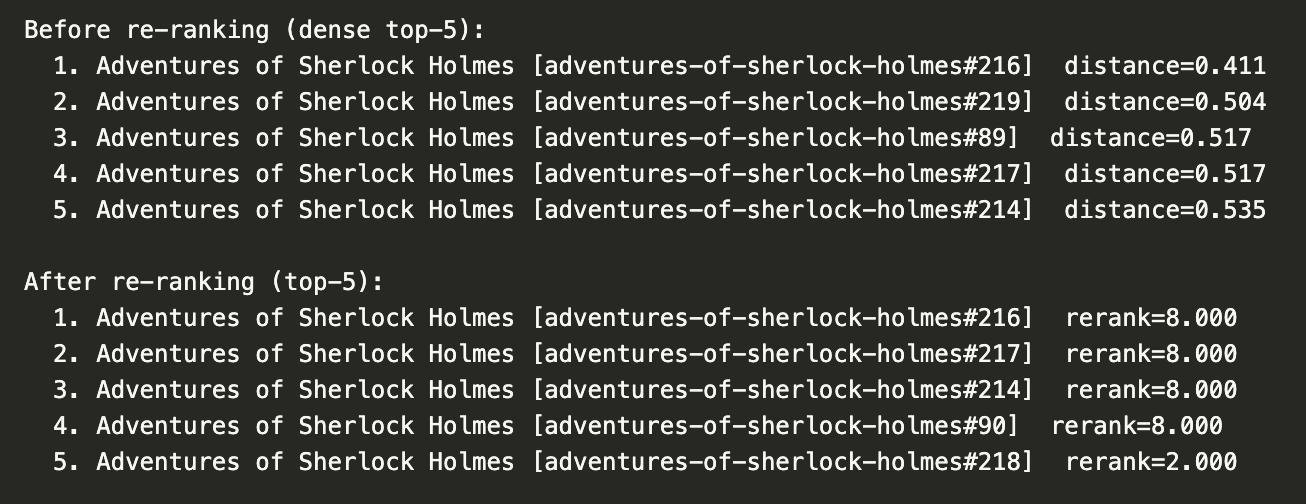